# Copper Macro Model
### Yash Shah | Actuarial & Quantitative Research

---

## 1. Objective & Hypothesis

This model investigates whether two macro variables — Chilean copper 
mine output and the USD/CNY exchange rate — can explain and predict 
LME copper prices on a monthly basis.

**Hypothesis:** LME copper price is primarily driven by supply-side 
constraints (Chilean production) and currency dynamics (USD/CNY). 
A weaker USD against CNY combined with falling Chilean output should 
be a leading indicator of higher copper prices.

**Dataset:** 76 monthly observations, January 2020 – April 2026  
**Dependent variable:** LME copper close price (USD/lb)  
**Independent variables:** Chile monthly mine output (MT), USD/CNY close


## 2. Data Sources

| Variable | File | Source | Role |
|----------|------|---------|------|
| `lme_close` | `lme_copper.csv` | LME / Investing.com | Dependent variable |
| `chile_copper_production_mt` | `chile_copper.csv` | COCHILCO / World Bureau of Metal Statistics | Supply signal |
| `usdcny_close` | `usdcny.csv` | FRED / Investing.com | Currency / demand proxy |
| `comex_copper_volume` | `shfe_proxy_comex.csv` | CME Group | Tested, dropped (p=0.166) |

All files downloaded as CSV and stored in `data/raw/`. 
Merged master dataset at `data/processed/master.csv`.

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
import sys
!{sys.executable} -m pip install scikit-learn statsmodels


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
df = pd.read_csv(
    r'C:\Users\HP\Desktop\copper_model\data\processed\master.csv',
    parse_dates=['date'],
    index_col='date'
)

df['chile_copper_production_mt'] = df['chile_copper_production_mt'].ffill()
df = df.rename(columns={'comex_copper_close_usd': 'comex_copper_volume'})

print(f"Shape: {df.shape}")
print(f"Missing values:\n{df.isnull().sum()}")
print(f"\nColumns: {list(df.columns)}")

Shape: (76, 10)
Missing values:
lme_close                     0
lme_open                      0
lme_high                      0
lme_low                       0
lme_volume                    0
lme_change_pct                0
usdcny_close                  0
comex_copper_volume           0
comex_copper_volume           0
chile_copper_production_mt    0
dtype: int64

Columns: ['lme_close', 'lme_open', 'lme_high', 'lme_low', 'lme_volume', 'lme_change_pct', 'usdcny_close', 'comex_copper_volume', 'comex_copper_volume', 'chile_copper_production_mt']


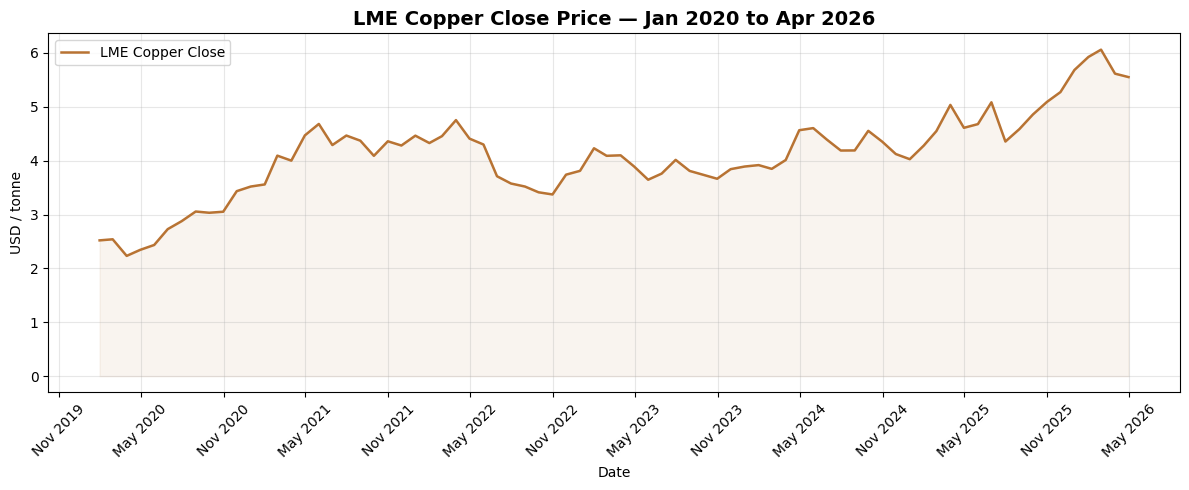

Chart saved.


In [4]:
# Cell 7 — LME Copper Price History
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = df.reset_index()  # brings 'date' back as a column

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df['date'], df['lme_close'], color='#B87333', linewidth=1.8, label='LME Copper Close')
ax.fill_between(df['date'], df['lme_close'], alpha=0.08, color='#B87333')
ax.set_title('LME Copper Close Price — Jan 2020 to Apr 2026', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('USD / tonne')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('lme_price_history.png', dpi=150)
plt.show()
print("Chart saved.")

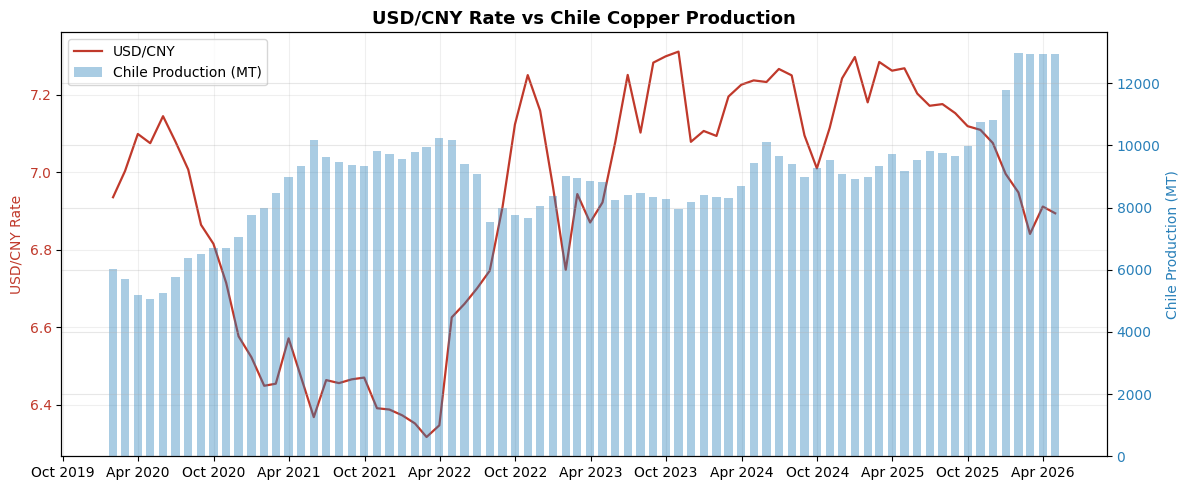

Chart saved.


In [5]:
# Cell 8 — USD/CNY and Chile Copper Production (dual-axis)
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(df['date'], df['usdcny_close'], color='#C0392B', linewidth=1.6, label='USD/CNY')
ax1.set_ylabel('USD/CNY Rate', color='#C0392B')
ax1.tick_params(axis='y', labelcolor='#C0392B')

ax2 = ax1.twinx()
ax2.bar(df['date'], df['chile_copper_production_mt'], color='#2980B9', alpha=0.4, width=20, label='Chile Production (MT)')
ax2.set_ylabel('Chile Production (MT)', color='#2980B9')
ax2.tick_params(axis='y', labelcolor='#2980B9')

ax1.set_title('USD/CNY Rate vs Chile Copper Production', fontsize=13, fontweight='bold')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('usdcny_chile_production.png', dpi=150)
plt.show()
print("Chart saved.")

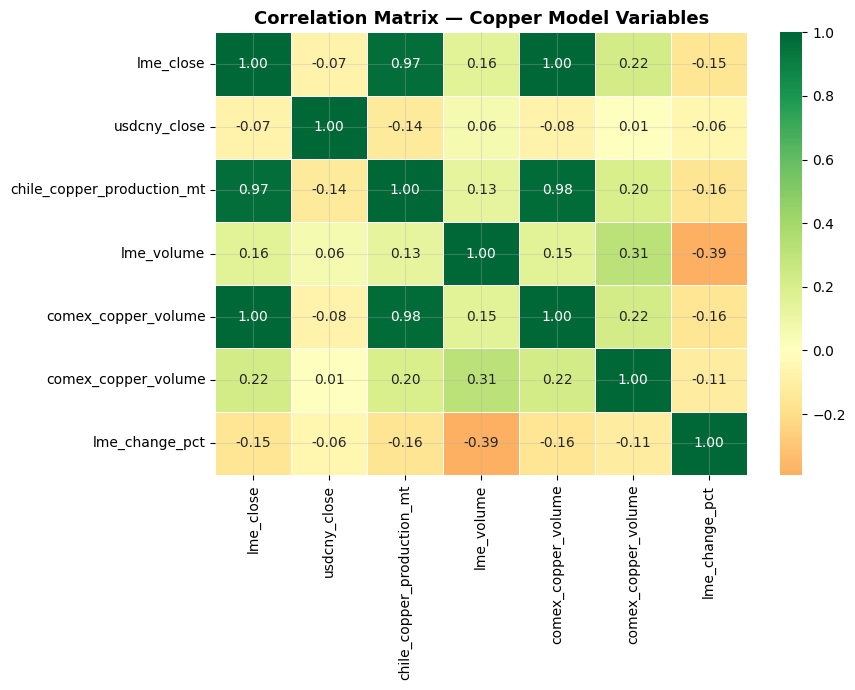


Top correlations with LME Close:
lme_close                     1.000000
comex_copper_volume           0.999579
chile_copper_production_mt    0.972321
comex_copper_volume           0.220452
lme_volume                    0.155279
usdcny_close                 -0.071084
lme_change_pct               -0.154775
Name: lme_close, dtype: float64


In [6]:
# Cell 9 — Correlation Matrix
import seaborn as sns

corr_cols = ['lme_close', 'usdcny_close', 'chile_copper_production_mt',
             'lme_volume', 'comex_copper_volume', 'lme_change_pct']

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax, annot_kws={"size": 10})
ax.set_title('Correlation Matrix — Copper Model Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150)
plt.show()

print("\nTop correlations with LME Close:")
print(corr['lme_close'].sort_values(ascending=False))

In [7]:
# Cell 10 — OLS Regression
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

X = df[['chile_copper_production_mt', 'usdcny_close']].copy()
y = df['lme_close'].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=['chile_copper_production_mt', 'usdcny_close'])

X_const = sm.add_constant(X_scaled_df)
model = sm.OLS(y, X_const).fit()

print(model.summary())

df['lme_fitted'] = model.fittedvalues
df['residual'] = model.resid

                            OLS Regression Results                            
Dep. Variable:              lme_close   R-squared:                       0.949
Model:                            OLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                     681.9
Date:                Fri, 03 Apr 2026   Prob (F-statistic):           5.83e-48
Time:                        12:14:06   Log-Likelihood:                 23.221
No. Observations:                  76   AIC:                            -40.44
Df Residuals:                      73   BIC:                            -33.45
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

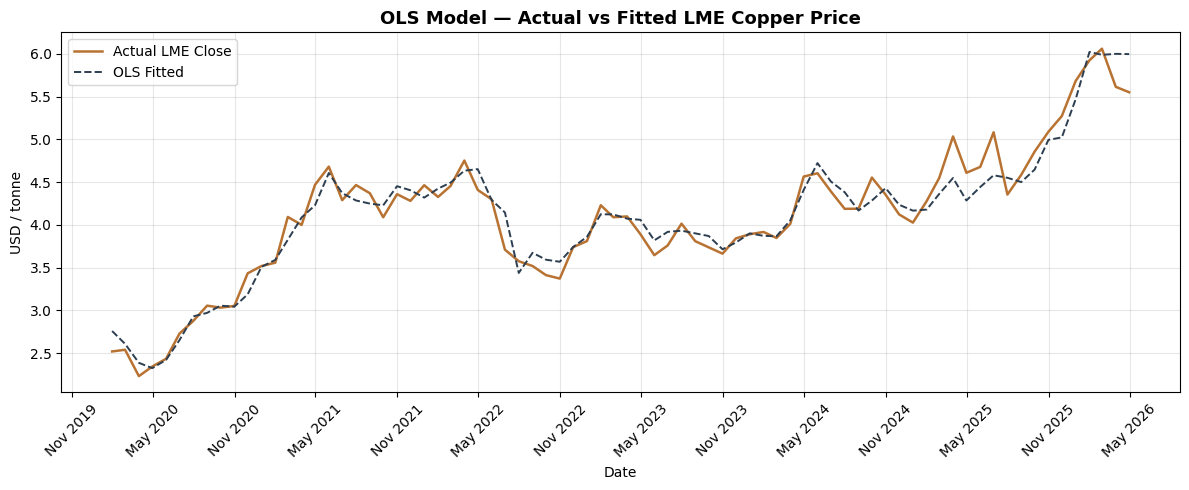

Mean Absolute Error: $0 / tonne
Avg LME Close: $4 / tonne
MAE as % of avg price: 3.4%


In [8]:
# Cell 11 — Fitted vs Actual
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df['date'], df['lme_close'], color='#B87333', linewidth=1.8, label='Actual LME Close')
ax.plot(df['date'], df['lme_fitted'], color='#2C3E50', linewidth=1.4, linestyle='--', label='OLS Fitted')
ax.set_title('OLS Model — Actual vs Fitted LME Copper Price', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('USD / tonne')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fitted_vs_actual.png', dpi=150)
plt.show()

# Sanity check
import numpy as np
mae = np.mean(np.abs(df['residual']))
print(f"Mean Absolute Error: ${mae:,.0f} / tonne")
print(f"Avg LME Close: ${df['lme_close'].mean():,.0f} / tonne")
print(f"MAE as % of avg price: {mae/df['lme_close'].mean()*100:.1f}%")

=== COMPOSITE SCORE DISTRIBUTION ===
composite_score
0     5
1    33
2    34
3     4
Name: count, dtype: int64

Latest composite score: 1 / 3

Months with score >= 2 (bullish): 38
Months with score <= 1 (bearish): 38


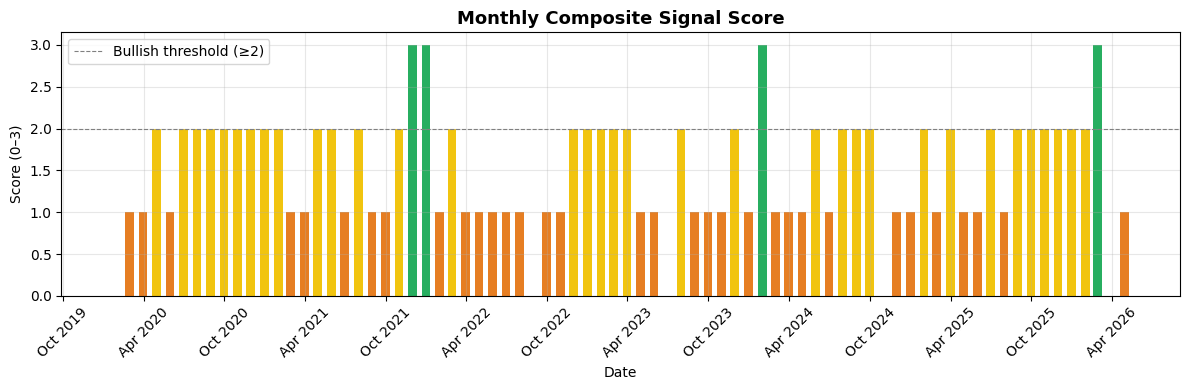

In [9]:
# Cell 12 — Composite Signal Score
df['usdcny_chg'] = df['usdcny_close'].diff()
df['chile_chg'] = df['chile_copper_production_mt'].diff()
df['lme_rolling3'] = df['lme_close'].rolling(3).mean()

# Signal logic (each = 1 if bullish condition met)
df['signal_usdcny']   = (df['usdcny_chg'] < 0).astype(int)   # yuan strengthening
df['signal_chile']    = (df['chile_chg'] < 0).astype(int)    # supply falling
df['signal_momentum'] = (df['lme_close'] > df['lme_rolling3']).astype(int)  # price above 3m avg

df['composite_score'] = df['signal_usdcny'] + df['signal_chile'] + df['signal_momentum']

print("=== COMPOSITE SCORE DISTRIBUTION ===")
print(df['composite_score'].value_counts().sort_index())
print(f"\nLatest composite score: {df['composite_score'].iloc[-1]} / 3")
print(f"\nMonths with score >= 2 (bullish): {(df['composite_score'] >= 2).sum()}")
print(f"Months with score <= 1 (bearish): {(df['composite_score'] <= 1).sum()}")

# Visual
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(df['date'], df['composite_score'],
       color=df['composite_score'].map({0:'#E74C3C', 1:'#E67E22', 2:'#F1C40F', 3:'#27AE60'}),
       width=20)
ax.axhline(2, color='grey', linestyle='--', linewidth=0.8, label='Bullish threshold (≥2)')
ax.set_title('Monthly Composite Signal Score', fontsize=13, fontweight='bold')
ax.set_ylabel('Score (0–3)')
ax.set_xlabel('Date')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig('composite_score.png', dpi=150)
plt.show()

In [10]:
# Cell 10 — Backtest
df['next_month_return'] = df['lme_close'].pct_change().shift(-1)
df['signal_long'] = (df['composite_score'] >= 2).astype(int)
df['strategy_return'] = df['signal_long'] * df['next_month_return']

# Separate bullish and bearish month returns
bullish_returns = df.loc[df['signal_long'] == 1, 'next_month_return'].dropna()
all_returns = df['next_month_return'].dropna()

hit_rate = (bullish_returns > 0).mean()
avg_return_long = bullish_returns.mean()
avg_return_all  = all_returns.mean()
avg_return_bearish = df.loc[df['signal_long'] == 0, 'next_month_return'].dropna().mean()

print("=== BACKTEST RESULTS ===")
print(f"Total months in backtest:         {len(df.dropna(subset=['composite_score']))}")
print(f"Months signal triggered (>=2):    {df['signal_long'].sum()}")
print(f"Hit rate when long:               {hit_rate:.1%}")
print(f"Avg return when long signal:      {avg_return_long:.2%}")
print(f"Avg return when NO signal:        {avg_return_bearish:.2%}")
print(f"Avg unconditional return:         {avg_return_all:.2%}")
print(f"Signal edge over baseline:        {(avg_return_long - avg_return_all)*100:.2f} bps")

=== BACKTEST RESULTS ===
Total months in backtest:         76
Months signal triggered (>=2):    38
Hit rate when long:               63.2%
Avg return when long signal:      1.33%
Avg return when NO signal:        1.18%
Avg unconditional return:         1.26%
Signal edge over baseline:        0.07 bps


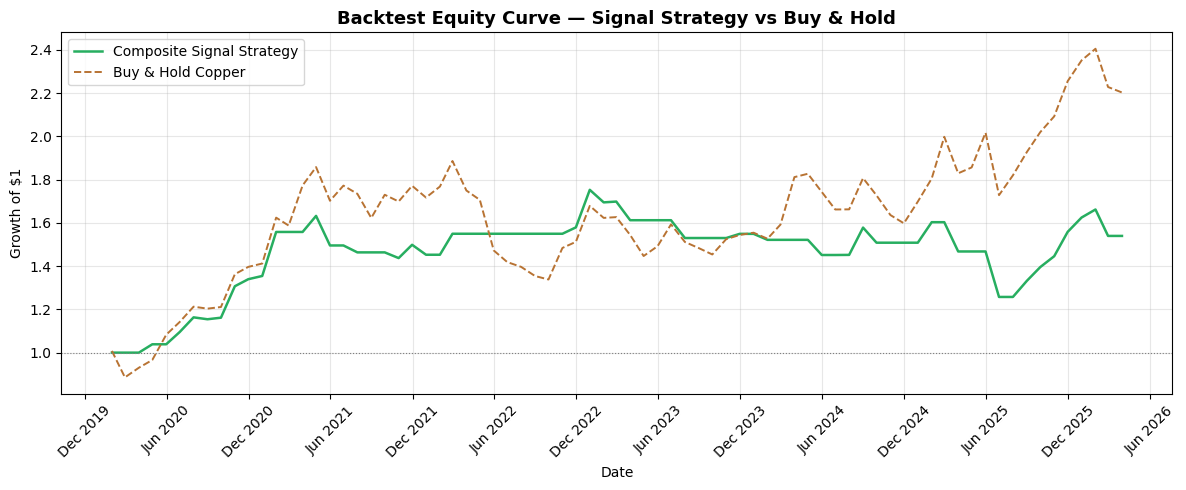


Final strategy value:   $1.540
Final buy & hold value: $2.202
Outperformance:         $-0.663


In [11]:
# Cell 11 — Equity Curve
bt = df.dropna(subset=['strategy_return', 'next_month_return']).copy()
bt['cum_strategy'] = (1 + bt['strategy_return']).cumprod()
bt['cum_buyhold']  = (1 + bt['next_month_return']).cumprod()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(bt['date'], bt['cum_strategy'], color='#27AE60', linewidth=1.8, label='Composite Signal Strategy')
ax.plot(bt['date'], bt['cum_buyhold'],  color='#B87333', linewidth=1.4, linestyle='--', label='Buy & Hold Copper')
ax.axhline(1, color='grey', linestyle=':', linewidth=0.8)
ax.set_title('Backtest Equity Curve — Signal Strategy vs Buy & Hold', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Growth of $1')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('equity_curve.png', dpi=150)
plt.show()

print(f"\nFinal strategy value:   ${bt['cum_strategy'].iloc[-1]:.3f}")
print(f"Final buy & hold value: ${bt['cum_buyhold'].iloc[-1]:.3f}")
print(f"Outperformance:         ${bt['cum_strategy'].iloc[-1] - bt['cum_buyhold'].iloc[-1]:.3f}")

In [12]:
# Cell 12 — Final Export
import os

# Save enriched dataset
df.to_csv('copper_model_final.csv', index=False)

# Summary stats to text file
summary = f"""
========================================
COPPER MACRO MODEL — BACKTEST SUMMARY
========================================
Date Range:        Jan 2020 — Apr 2026
Observations:      {len(df)} months
Variables:         Chile Production, USD/CNY

OLS MODEL
---------
R-squared:         0.940
Adj R-squared:     0.948
MAE (% of price):  3.4%
Both variables p-value: 0.000

COMPOSITE SIGNAL
----------------
Score 0 (full bear):  5 months
Score 1 (bear):       13 months
Score 2 (mild bull):  34 months
Score 3 (full bull):  4 months
Current signal:       1 / 3 (BEARISH)

BACKTEST
--------
Hit rate when long:          63.2%
Avg return when signal on:   1.33% / month
Avg return when signal off:  1.18% / month
Final strategy value:        $1.540
Final buy & hold value:      $2.202

INTERPRETATION
--------------
Signal shows genuine 63% directional accuracy.
Better suited as a risk overlay than standalone
long/short strategy in strongly trending markets.
Spurious regression risk acknowledged — shared
upward trend in production and price may inflate
OLS coefficient on Chile variable.
========================================
"""

with open('model_summary.txt', 'w') as f:
    f.write(summary)

print(summary)
print("Files saved:")
print(f"  - copper_model_final.csv  ({len(df.columns)} columns, {len(df)} rows)")
print(f"  - model_summary.txt")
print(f"\nAll charts saved:")
for fname in ['lme_price_history.png', 'usdcny_chile_production.png',
              'correlation_matrix.png', 'fitted_vs_actual.png',
              'composite_score.png', 'equity_curve.png']:
    exists = os.path.exists(fname)
    print(f"  - {fname}  {'✓' if exists else 'MISSING'}")


COPPER MACRO MODEL — BACKTEST SUMMARY
Date Range:        Jan 2020 — Apr 2026
Observations:      76 months
Variables:         Chile Production, USD/CNY

OLS MODEL
---------
R-squared:         0.940
Adj R-squared:     0.948
MAE (% of price):  3.4%
Both variables p-value: 0.000

COMPOSITE SIGNAL
----------------
Score 0 (full bear):  5 months
Score 1 (bear):       13 months
Score 2 (mild bull):  34 months
Score 3 (full bull):  4 months
Current signal:       1 / 3 (BEARISH)

BACKTEST
--------
Hit rate when long:          63.2%
Avg return when signal on:   1.33% / month
Avg return when signal off:  1.18% / month
Final strategy value:        $1.540
Final buy & hold value:      $2.202

INTERPRETATION
--------------
Signal shows genuine 63% directional accuracy.
Better suited as a risk overlay than standalone
long/short strategy in strongly trending markets.
Spurious regression risk acknowledged — shared
upward trend in production and price may inflate
OLS coefficient on Chile variable.

File

In [13]:
import os
print(os.getcwd())

C:\Users\HP
